**Aprendizaje Automático**

---
*Nombre:* John David Ortega Echeverría
*Curso:* CDDEIA-ELNO-4-2

# Naive Bayes: GaussianNB y MultinomialNB


In [26]:
# IMPORTAR LIBRERÍAS

# load_breast_cancer:
# dataset numérico para trabajar GaussianNB
from sklearn.datasets import load_breast_cancer

# fetch_20newsgroups:
# dataset de texto para trabajar MultinomialNB
from sklearn.datasets import fetch_20newsgroups

# train_test_split:
# separa datos en entrenamiento y prueba
from sklearn.model_selection import train_test_split

# GaussianNB:
# Naive Bayes para variables numéricas continuas
from sklearn.naive_bayes import GaussianNB

# MultinomialNB:
# Naive Bayes para conteos o frecuencias
from sklearn.naive_bayes import MultinomialNB

# Métricas para evaluar clasificación
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import RocCurveDisplay

# CountVectorizer:
# convierte texto en bolsa de palabras
from sklearn.feature_extraction.text import CountVectorizer

# pandas:
# para construir tablas de métricas
import pandas as pd

# matplotlib:
# para gráficos
import matplotlib.pyplot as plt

## GaussianNB con datos numéricos

In [27]:
# CARGAR EL DATASET NUMÉRICO

# Cargamos el dataset completo
datos = load_breast_cancer()

# X guarda las variables predictoras
X = datos.data

# y guarda la clase objetivo
y = datos.target

# Mostramos dimensiones para entender el tamaño del problema
print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

# Mostramos nombres de clases
print("Clases:", datos.target_names)

Dimensiones de X: (569, 30)
Dimensiones de y: (569,)
Clases: ['malignant' 'benign']


In [28]:
# DIVIDIR EN ENTRENAMIENTO Y PRUEBA

# train_test_split separa el dataset
# test_size=0.2 deja el 20% para prueba
# random_state fija la semilla para reproducibilidad
# stratify=y mantiene la proporción de clases
X_train = None
X_test = None
y_train = None
y_test = None

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=23,
    stratify=y
)

# Tamaños resultantes
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (455, 30)
X_test: (114, 30)
y_train: (455,)
y_test: (114,)


In [29]:
# Instancia del modelo GaussianNB
modelo_g = GaussianNB()

In [30]:
# ENTRENAR EL MODELO GAUSSIANO

# fit hace que el modelo aprenda con los datos de entrenamiento
# Aquí calcula lo necesario para estimar probabilidades por clase
modelo_g.fit(X_train, y_train)

GaussianNB()

In [31]:
# PREDICCIONES CON EL MODELO GAUSSIANO

# predict devuelve la clase estimada para cada fila de prueba
y_pred_g = modelo_g.predict(X_test)

# predict_proba devuelve probabilidades para cada clase
# [:, 1] toma la probabilidad de la clase positiva
y_prob_g = modelo_g.predict_proba(X_test)[:, 1]

In [32]:
# CALCULAR MÉTRICAS DEL MODELO GAUSSIANO

# Accuracy:
# porcentaje total de aciertos
accuracy_g = accuracy_score(y_test, y_pred_g)

# Precisión:
# de los positivos predichos, cuántos fueron correctos
precision_g = precision_score(y_test, y_pred_g)

# Recall:
# de los positivos reales, cuántos detectó el modelo
recall_g = recall_score(y_test, y_pred_g)

# F1-score:
# equilibrio entre precisión y recall
f1_g = f1_score(y_test, y_pred_g)

# ROC-AUC:
# mide la capacidad de separar clases usando probabilidades
roc_auc_g = roc_auc_score(y_test, y_prob_g)

# Guardamos todo en un DataFrame para verlo ordenado
metricas_g = pd.DataFrame({
    "Modelo": ["GaussianNB"],
    "Accuracy": [accuracy_g],
    "Precisión": [precision_g],
    "Recall": [recall_g],
    "F1-score": [f1_g],
    "ROC-AUC": [roc_auc_g]
})

print("Métricas del modelo GaussianNB")
display(metricas_g)

Métricas del modelo GaussianNB


,Modelo,Accuracy,Precisión,Recall,F1-score,ROC-AUC
0,GaussianNB,0.929825,0.932432,0.958333,0.945205,0.978175


In [33]:
# REPORTE DE CLASIFICACIÓN DEL MODELO GAUSSIANO

# classification_report resume precision, recall y f1-score por clase
print("Reporte de clasificación - GaussianNB\n")
print(classification_report(y_test, y_pred_g, target_names=datos.target_names))

Reporte de clasificación - GaussianNB

              precision    recall  f1-score   support

   malignant       0.93      0.88      0.90        42
      benign       0.93      0.96      0.95        72

    accuracy                           0.93       114
   macro avg       0.93      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



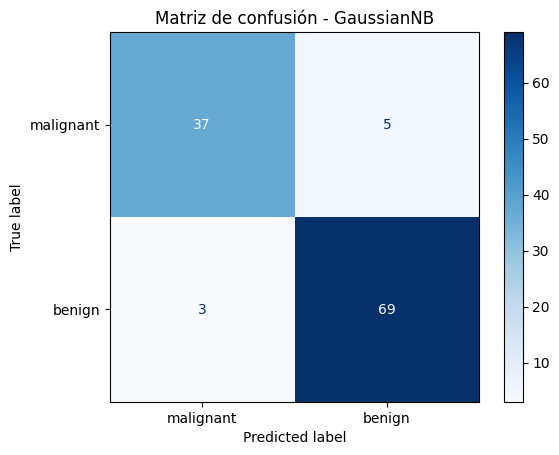

In [34]:
# MATRIZ DE CONFUSIÓN DEL MODELO GAUSSIANO

# confusion_matrix construye la matriz de errores y aciertos
cm_g = confusion_matrix(y_test, y_pred_g)

# Creamos el objeto para mostrarla mejor
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_g,
    display_labels=datos.target_names
)

# Dibujamos la matriz
disp.plot(cmap="Blues", values_format="d")

# Título del gráfico
plt.title("Matriz de confusión - GaussianNB")

# Mostramos el gráfico
plt.show()

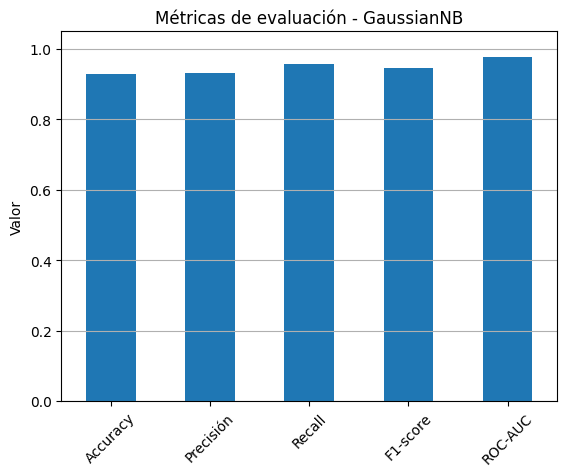

In [35]:
# GRÁFICO DE MÉTRICAS DEL MODELO GAUSSIANO

# set_index pone el nombre del modelo como índice
# .T transpone para que las métricas queden en el eje x
metricas_g.set_index("Modelo").T.plot(
    kind="bar",
    legend=False
)

plt.title("Métricas de evaluación - GaussianNB")
plt.ylabel("Valor")
plt.ylim(0, 1.05)
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

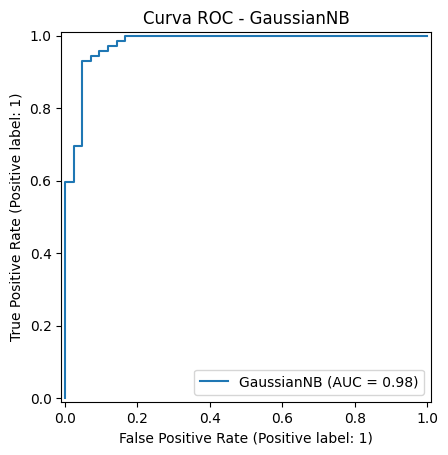

In [36]:
# CURVA ROC DEL MODELO GAUSSIANO

# from_estimator calcula y dibuja la curva ROC directamente desde el modelo
RocCurveDisplay.from_estimator(modelo_g, X_test, y_test)

plt.title("Curva ROC - GaussianNB")
plt.show()

## MultinomialNB con texto

En esta parte usamos texto.

Tomamos dos categorías del dataset 20newsgroups y luego las convertimos en una bolsa de palabras con CountVectorizer.

Como aquí trabajamos con conteos, la variante correcta es MultinomialNB.


In [37]:
# DEFINIR CATEGORÍAS DE TEXTO

# Escogemos dos categorías para hacer una clasificación binaria
categorias = [
    "sci.space",
    "rec.sport.baseball"
]

In [38]:
# CARGAR EL DATASET DE TEXTO

# subset='train' carga el conjunto de entrenamiento original del dataset
# categories filtra solo las categorías elegidas
datos_m = fetch_20newsgroups(
    subset="train",
    categories=categorias
)

# Mostramos información básica
print("Cantidad de documentos:", len(datos_m.data))
print("Clases:", datos_m.target_names)

Cantidad de documentos: 1190
Clases: ['rec.sport.baseball', 'sci.space']


In [39]:
# VECTORIZAR EL TEXTO

# CountVectorizer transforma los textos en columnas de palabras
# binary=True marca si la palabra aparece o no aparece
vectorizador = CountVectorizer(binary=True)

# fit_transform aprende el vocabulario y transforma los documentos
X_m = vectorizador.fit_transform(datos_m.data)

# y_m guarda las clases objetivo
y_m = datos_m.target

# Mostramos dimensiones de la matriz de texto
print("Dimensiones de X_m:", X_m.shape)
print("Dimensiones de y_m:", y_m.shape)

Dimensiones de X_m: (1190, 21621)
Dimensiones de y_m: (1190,)


In [40]:
# DIVIDIR EN ENTRENAMIENTO Y PRUEBA PARA TEXTO

# Aquí usamos 30% para prueba
# random_state fija la semilla
# stratify mantiene la proporción de clases
X_train_m = None
X_test_m = None
y_train_m = None
y_test_m = None

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_m,
    y_m,
    test_size=0.3,
    random_state=30,
    stratify=y_m
)

print("X_train_m:", X_train_m.shape)
print("X_test_m:", X_test_m.shape)
print("y_train_m:", y_train_m.shape)
print("y_test_m:", y_test_m.shape)

X_train_m: (833, 21621)
X_test_m: (357, 21621)
y_train_m: (833,)
y_test_m: (357,)


In [41]:
# CREAR EL MODELO MULTINOMIAL

# Creamos una instancia de MultinomialNB
modelo_m = MultinomialNB()

In [42]:
# ENTRENAR EL MODELO MULTINOMIAL

# El modelo aprende con la matriz de conteos del texto
modelo_m.fit(X_train_m, y_train_m)

MultinomialNB()

In [43]:
# HACER PREDICCIONES CON EL MODELO MULTINOMIAL

# Predicción de clase
y_pred_m = modelo_m.predict(X_test_m)

# Probabilidad de la clase positiva
y_prob_m = modelo_m.predict_proba(X_test_m)[:, 1]

In [44]:
# CALCULAR MÉTRICAS DEL MODELO MULTINOMIAL

accuracy_m = accuracy_score(y_test_m, y_pred_m)
precision_m = precision_score(y_test_m, y_pred_m)
recall_m = recall_score(y_test_m, y_pred_m)
f1_m = f1_score(y_test_m, y_pred_m)
roc_auc_m = roc_auc_score(y_test_m, y_prob_m)

metricas_m = pd.DataFrame({
    "Modelo": ["MultinomialNB"],
    "Accuracy": [accuracy_m],
    "Precisión": [precision_m],
    "Recall": [recall_m],
    "F1-score": [f1_m],
    "ROC-AUC": [roc_auc_m]
})

print("Métricas del modelo MultinomialNB")
display(metricas_m)

Métricas del modelo MultinomialNB


,Modelo,Accuracy,Precisión,Recall,F1-score,ROC-AUC
0,MultinomialNB,0.994398,0.994382,0.994382,0.994382,0.998399


In [45]:
# REPORTE DE CLASIFICACIÓN DEL MODELO MULTINOMIAL

print("Reporte de clasificación - MultinomialNB\n")
print(classification_report(y_test_m, y_pred_m, target_names=datos_m.target_names))

Reporte de clasificación - MultinomialNB

                    precision    recall  f1-score   support

rec.sport.baseball       0.99      0.99      0.99       179
         sci.space       0.99      0.99      0.99       178

          accuracy                           0.99       357
         macro avg       0.99      0.99      0.99       357
      weighted avg       0.99      0.99      0.99       357



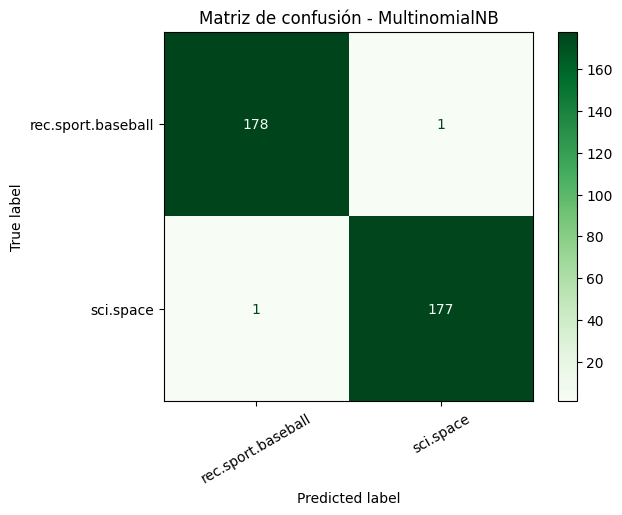

In [46]:
# MATRIZ DE CONFUSIÓN DEL MODELO MULTINOMIAL

cm_m = confusion_matrix(y_test_m, y_pred_m)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_m,
    display_labels=datos_m.target_names
)

disp.plot(cmap="Greens", values_format="d")
plt.title("Matriz de confusión - MultinomialNB")
plt.xticks(rotation=30)
plt.show()

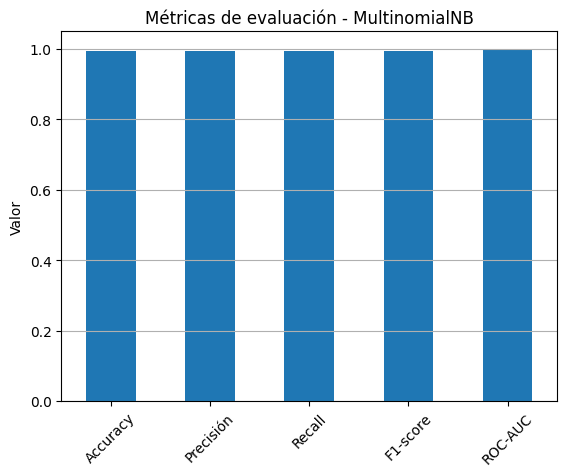

In [47]:
# GRÁFICO DE MÉTRICAS DEL MODELO MULTINOMIAL

metricas_m.set_index("Modelo").T.plot(
    kind="bar",
    legend=False
)

plt.title("Métricas de evaluación - MultinomialNB")
plt.ylabel("Valor")
plt.ylim(0, 1.05)
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

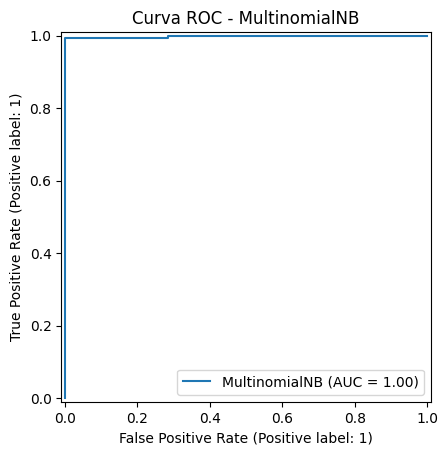

In [48]:
# CURVA ROC DEL MODELO MULTINOMIAL

RocCurveDisplay.from_estimator(modelo_m, X_test_m, y_test_m)

plt.title("Curva ROC - MultinomialNB")
plt.show()

## Parte 3. Comparación final

Ahora juntamos las métricas de ambos modelos para compararlos en una sola tabla y en un solo gráfico.


In [49]:
# UNIR LAS MÉTRICAS DE LOS DOS MODELOS

# concat une los dos DataFrames uno debajo del otro
metricas_comparacion = pd.concat(
    [metricas_g, metricas_m],
    ignore_index=True
)

display(metricas_comparacion)

,Modelo,Accuracy,Precisión,Recall,F1-score,ROC-AUC
0,GaussianNB,0.929825,0.932432,0.958333,0.945205,0.978175
1,MultinomialNB,0.994398,0.994382,0.994382,0.994382,0.998399


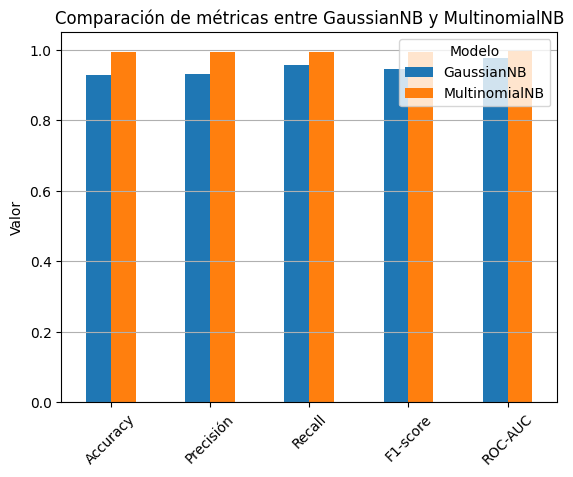

In [50]:
# GRÁFICO COMPARATIVO FINAL

metricas_comparacion.set_index("Modelo")[[
    "Accuracy",
    "Precisión",
    "Recall",
    "F1-score",
    "ROC-AUC"
]].T.plot(kind="bar")

plt.title("Comparación de métricas entre GaussianNB y MultinomialNB")
plt.ylabel("Valor")
plt.ylim(0, 1.05)
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.legend(title="Modelo")
plt.show()